In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
# Course utilities (do not modify this cell)        
import sys
import os
base_path = os.path.expanduser("~/Documents/GitHub/Signals_and_Systems")
sys.path.insert(0, base_path)
sys.path.insert(0, os.path.join(base_path, "courseutils"))

import basic_material as bm
print("Basic Material version:", bm.__version__)
bm.setup_environment()

import control_materials as cm
print("Control Material version:", cm.__version__)
cm.setup_environment()


Basic Material version: 16.002-0.1


Control Material version: 16.002-0.1


In [3]:
colors = bm.get_colors()
j = complex(0,1)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.offsetbox import AnchoredText
import sympy as sp

import control as ct
import control.matlab as cmat

from scipy.fftpack import fft, ifft, fftfreq, fftshift  

import warnings
warnings.filterwarnings(
    "ignore",
    message="divide by zero encountered in divide"
)
warnings.filterwarnings(
    "ignore",
    message="invalid value encountered in divide"
)

In [4]:
N = 2**14 # large number of samples
Tf = 20 # final time
fs = N/Tf # sampling frequency
T0 = .20 # period of the comb
# time domain comb
DiracComb = np.zeros(N)
DiracComb[::int(fs*T0)] = 1
# frequency domain comb 
DiracComb_f = fft(DiracComb)
t = np.linspace(0, Tf, N, endpoint=False)

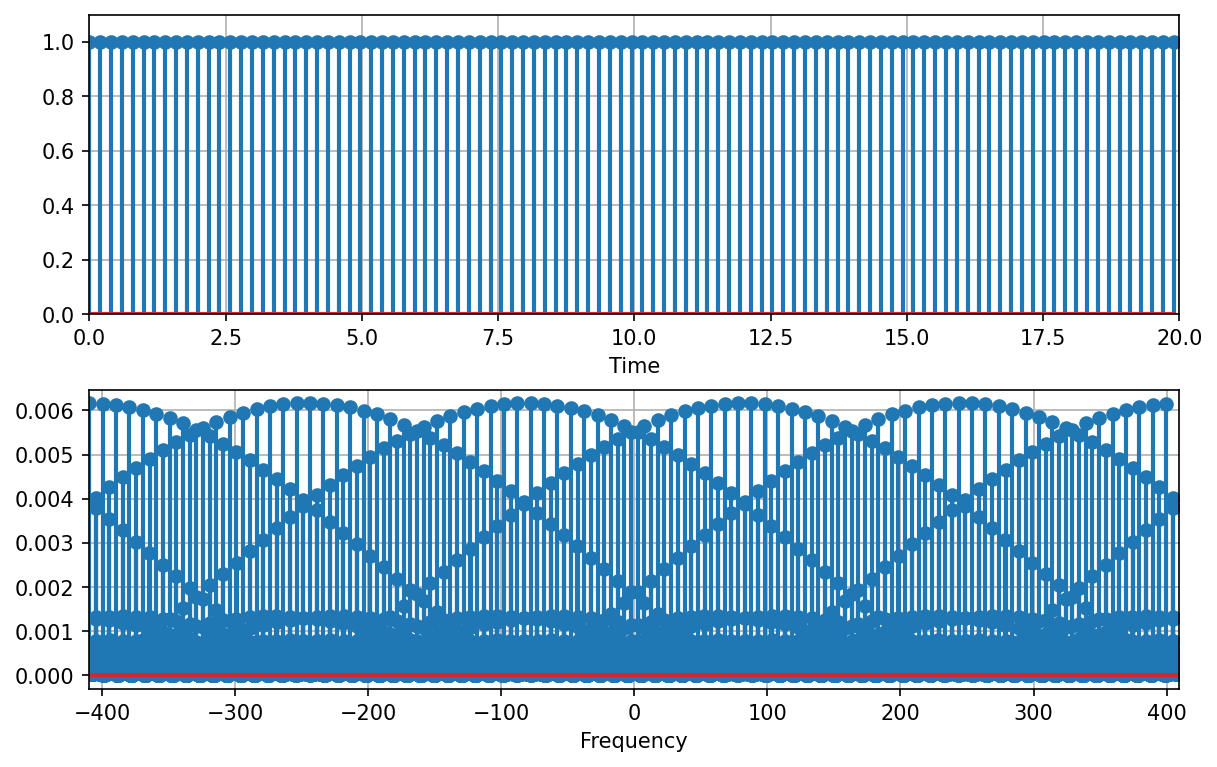

In [5]:
fig,axs = plt.subplots(2,1,figsize=(8, 5),dpi=150,constrained_layout = True)
axs[0].stem(t[::int(fs*T0)],DiracComb[DiracComb > 0])
axs[0].set_ylim([0, 1.1])
axs[0].set_xlim([0, Tf])
axs[0].set_xlabel("Time")

f = fftshift(fftfreq(N, 1/fs))
axs[1].stem(f, abs(DiracComb_f)/N)  # Actually there is a factor N in the fft
#axs[1].set_ylim([0, 1.1 * 1 / T0])
axs[1].set_xlabel("Frequency")
plt.show()

In [6]:
def tri(t, p = 1):   # tri(t/p)
    if t < -p:
        return 0
    if t < 0:
        return 1 + t/p
    if t <= p:
        return 1 - t/p
    else:
        return 0
    
def rect(t,p):  # rect(t/p)
    if np.isscalar(t):
        if t < -p/2:
            return 0
        if t <= p/2:
            return 1
        else:
            return 0
    else:
        y = np.zeros_like(t)
        y[np.where((-1/2 <= tt/p)*(tt/p <= 1/2))] = 1.0
        return y    

In [7]:
tlim = 1
tt = np.linspace(-tlim, tlim, 2**13)
flim = 2*np.pi
ff = np.linspace(-flim, flim, 2**12)

In [8]:
rect_numerical = rect(tt,1)

In [9]:
z = np.convolve(DiracComb_f, rect_numerical)

/Users/jonathanhow/Jon/venv312/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/jonathanhow/Jon/venv312/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


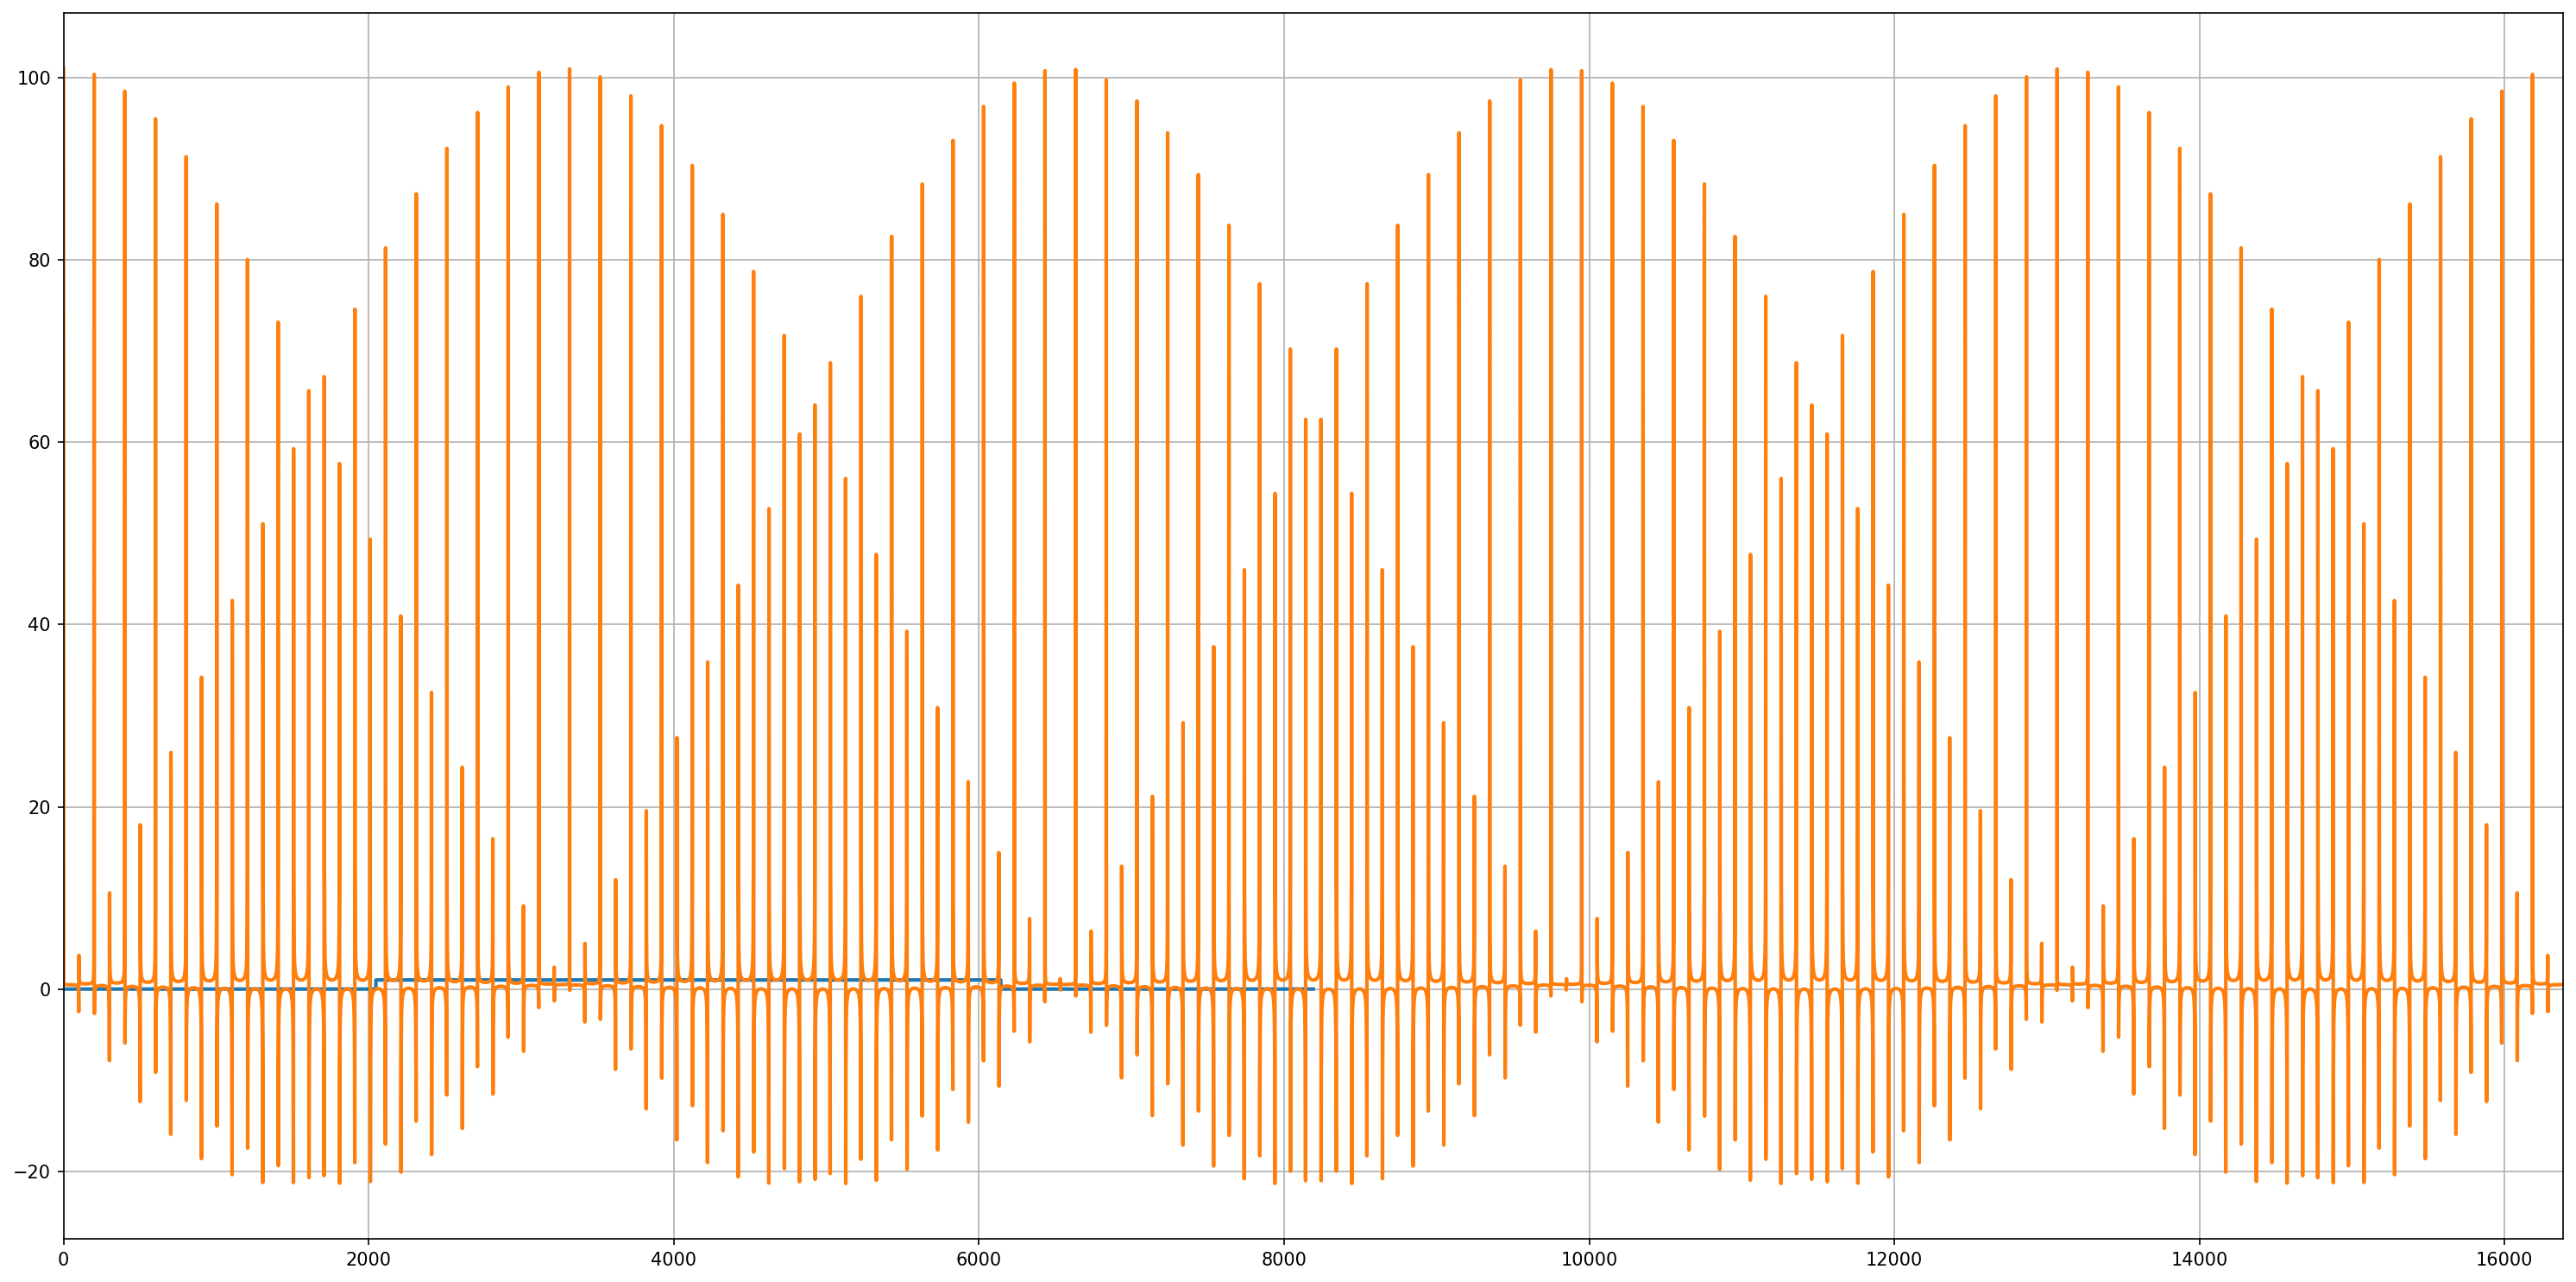

In [10]:
plt.plot(rect_numerical)
plt.plot(DiracComb_f)

Text(0.5, 0, 'Time')

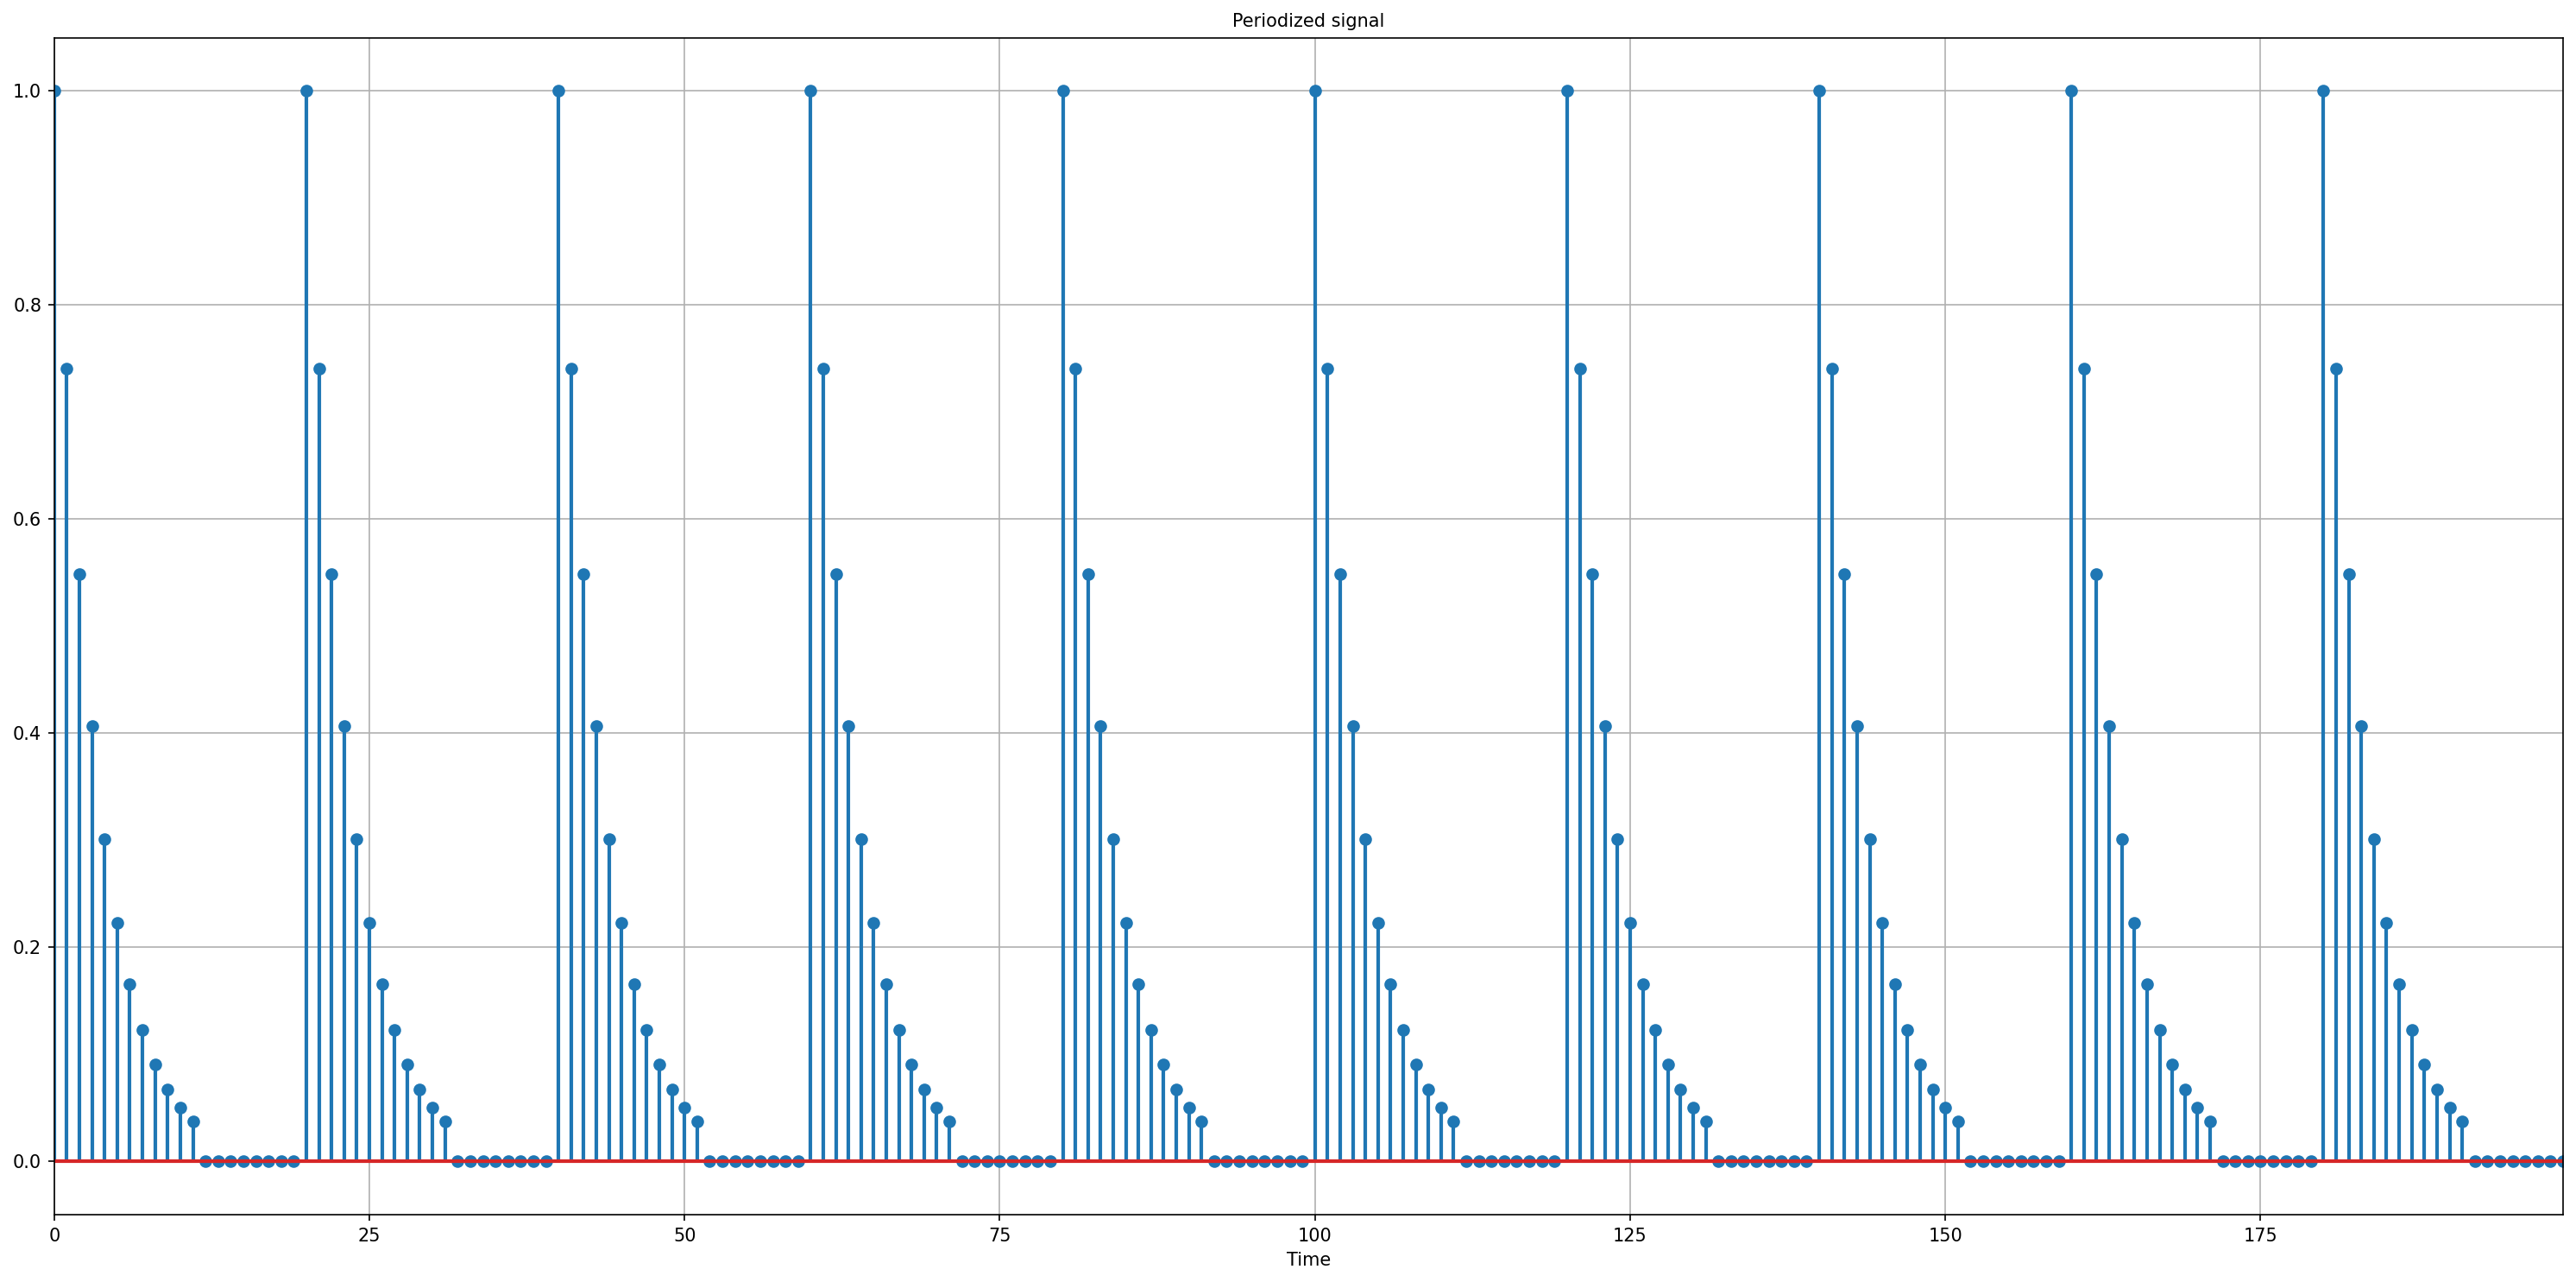

In [11]:
%matplotlib inline
N = 200
L0 = 20
L = 12  # L is the length of the pulse
DiracComb = np.zeros(N)
DiracComb[::L0] = 1
pulse = np.zeros(40)
pulse[0:L] = np.exp(-0.3*np.arange(L))
z = np.convolve(DiracComb, pulse)
plt.stem(z[0:200])
plt.title('Periodized signal')
plt.xlabel('Time')


In [12]:
pulse

array([   1.000,    0.741,    0.549,    0.407,    0.301,    0.223,
          0.165,    0.122,    0.091,    0.067,    0.050,    0.037,
          0.000,    0.000,    0.000,    0.000,    0.000,    0.000,
          0.000,    0.000,    0.000,    0.000,    0.000,    0.000,
          0.000,    0.000,    0.000,    0.000,    0.000,    0.000,
          0.000,    0.000,    0.000,    0.000,    0.000,    0.000,
          0.000,    0.000,    0.000,    0.000])